# Auditoría reproducible del dataset

**Prueba técnica de Analítica y Automatización Digital**  
Fuente: `data/raw/Digotec_Prueba_Analitica_Automatizacion_Dataset.tsv`

## Resumen ejecutivo (tl;dr)

El archivo contiene **22.455 registros, 15 columnas y 2.200 clientes**. La auditoría encontró **113 duplicados exactos**, valores categóricos escritos de varias formas, **89 fechas en formato no ISO**, 178 ciudades nulas y 136 saldos nulos.

El riesgo principal es la granularidad: los datos de producto se repiten entre registros e interacciones. Sumar `saldo_producto` directamente produce aproximadamente **USD 169,87 millones**, frente a **USD 77,36 millones** después de consolidar una fila por cliente-producto. En tarjetas, la inflación es **8,94 veces**.

Los nulos no tienen una sola causa. Cupo, categoría de consumo y algunos vencimientos son ausencias estructurales; ciudad y saldo requieren tratamiento. Los valores negativos y extremos se conservarán con banderas porque la estadística, por sí sola, no demuestra que sean errores.

**Alcance:** este notebook diagnostica y propone reglas. No modifica el TSV, no exporta datos limpios y no calcula Lovers ni recomendaciones comerciales definitivas.

## Contexto y método

La prueba solicita transformar una base imperfecta en una solución confiable y explicar las decisiones. Antes de limpiar, se revisan seis dimensiones de calidad: completitud, unicidad, validez, consistencia, granularidad y distribución.

### Supuestos clave

- `N/A` y las cadenas vacías representan ausencia o “no aplica”, según producto y columna.
- Una combinación cliente-producto representa un producto porque saldo, cupo y vencimiento no presentan múltiples valores no nulos.
- La fecha de corte será la máxima fecha de movimiento observada, no la fecha actual del equipo.
- Sin identificador transaccional, los duplicados exactos son candidatos razonables de eliminación, pero esto sigue siendo un supuesto.

### 1. Preparar el entorno

In [1]:
from pathlib import Path
import hashlib
import platform
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

pd.set_option("display.max_columns", 20)
pd.set_option("display.max_rows", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")
sns.set_theme(style="whitegrid", palette="deep")

environment = pd.DataFrame(
    {
        "Componente": ["Python", "pandas", "NumPy", "Matplotlib", "Seaborn", "Sistema"],
        "Versión": [
            sys.version.split()[0],
            pd.__version__,
            np.__version__,
            __import__("matplotlib").__version__,
            sns.__version__,
            platform.system(),
        ],
    }
)
display(environment)

,Componente,Versión
0,Python,3.12.14
1,pandas,3.0.5
2,NumPy,2.5.3
3,Matplotlib,3.11.1
4,Seaborn,0.13.2
5,Sistema,Darwin


### 2. Localizar y verificar la fuente

In [2]:
SOURCE_NAME = "Digotec_Prueba_Analitica_Automatizacion_Dataset.tsv"
EXPECTED_SHA256 = "4d59a7095f418a9d34276431924cc22540a125dba884fb72421d9d54a43c4115"

current_directory = Path.cwd().resolve()
root_candidates = [current_directory, current_directory.parent]
PROJECT_ROOT = next(
    (
        candidate
        for candidate in root_candidates
        if (candidate / "data" / "raw" / SOURCE_NAME).exists()
    ),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "No se encontró el TSV. Ejecute el notebook desde la raíz o desde analysis/."
    )

DATA_PATH = PROJECT_ROOT / "data" / "raw" / SOURCE_NAME
source_hash = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()
source_size_mb = DATA_PATH.stat().st_size / 1024**2

source_information = pd.DataFrame(
    {
        "Propiedad": ["Archivo", "Tamaño (MB)", "SHA-256", "Integridad"],
        "Valor": [
            str(DATA_PATH.relative_to(PROJECT_ROOT)),
            round(source_size_mb, 2),
            source_hash,
            "Coincide" if source_hash == EXPECTED_SHA256 else "No coincide",
        ],
    }
)
display(source_information)
assert source_hash == EXPECTED_SHA256, "El archivo fuente cambió desde la Fase 0."

,Propiedad,Valor
0,Archivo,data/raw/Digotec_Prueba_Analitica_Automatizaci...
1,Tamaño (MB),2.59
2,SHA-256,4d59a7095f418a9d34276431924cc22540a125dba884fb...
3,Integridad,Coincide


## Datos

### 3. Carga controlada

Se realizan dos lecturas. La primera conserva literalmente `N/A` y cadenas vacías para auditar el origen. La segunda interpreta esos valores como ausencias para medir la calidad analítica. Ninguna lectura modifica el archivo.

In [3]:
data_text = pd.read_csv(
    DATA_PATH,
    sep="	",
    dtype="string",
    keep_default_na=False,
)

data = pd.read_csv(
    DATA_PATH,
    sep="	",
    na_values=["", "N/A"],
    keep_default_na=True,
    dtype={"cliente_id": "string", "nombre_cliente": "string"},
)

load_comparison = pd.DataFrame(
    {
        "Lectura": ["Textual", "Tipada"],
        "Filas": [len(data_text), len(data)],
        "N/A literales en categoría": [
            int((data_text["categoria_consumo"] == "N/A").sum()),
            int((data["categoria_consumo"].astype("string") == "N/A").sum()),
        ],
        "Nulos en categoría": [
            int(data_text["categoria_consumo"].isna().sum()),
            int(data["categoria_consumo"].isna().sum()),
        ],
    }
)
display(load_comparison)
display(data.head(5))

,Lectura,Filas,N/A literales en categoría,Nulos en categoría
0,Textual,22455,7513,0
1,Tipada,22455,0,7513


,cliente_id,nombre_cliente,segmento_cliente,ciudad,edad,ingreso_estimado,producto,saldo_producto,cupo_credito,fecha_vencimiento,fecha_movimiento,categoria_consumo,monto_consumo,canal,estado_producto
0,C000728,Cliente 0728,Mass,Loja,50,"1,019.90",Cuenta de Ahorros,"1,498.82",NaN,NaN,2026-01-15,NaN,0.00,Branch,Activo
1,C001264,Cliente 1264,Mass,Guayaquil,57,471.10,Crédito Vehicular,"20,725.80",NaN,2029-11-14,2026-03-20,NaN,0.00,App,Activo
2,C001515,Cliente 1515,Joven,Manta,45,639.34,Tarjeta de Crédito,689.27,"1,200.00",2029-03-16,2025-11-06,Food,16.63,Branch,Activo
3,C002171,Cliente 2171,Mass,Guayaquil,23,"1,159.30",Cuenta de Ahorros,"5,001.88",NaN,NaN,2025-06-09,NaN,0.00,App,Activo
4,C001848,Cliente 1848,Premium,Guayaquil,46,"3,037.26",Tarjeta de Crédito,"1,955.00","8,200.00",2028-12-28,2025-03-04,Food,51.91,App,Activo


### 4. Estructura y diccionario de datos

In [4]:
structural_summary = pd.DataFrame(
    {
        "Métrica": ["Filas", "Columnas", "Clientes únicos", "Memoria (MB)"],
        "Valor": [
            data.shape[0],
            data.shape[1],
            data["cliente_id"].nunique(),
            round(data.memory_usage(deep=True).sum() / 1024**2, 2),
        ],
    }
)
display(structural_summary)

field_descriptions = {
    "cliente_id": ("Identificador único del cliente", "texto"),
    "nombre_cliente": ("Nombre sintético del cliente", "texto"),
    "segmento_cliente": ("Segmento comercial del cliente", "categoría"),
    "ciudad": ("Ciudad registrada", "categoría"),
    "edad": ("Edad del cliente", "entero"),
    "ingreso_estimado": ("Ingreso mensual estimado", "decimal"),
    "producto": ("Producto financiero asociado", "categoría"),
    "saldo_producto": ("Saldo del producto", "decimal"),
    "cupo_credito": ("Cupo asignado cuando aplica", "decimal"),
    "fecha_vencimiento": ("Vencimiento del producto cuando aplica", "fecha"),
    "fecha_movimiento": ("Fecha del movimiento o registro", "fecha"),
    "categoria_consumo": ("Categoría de consumo de tarjeta", "categoría"),
    "monto_consumo": ("Monto de consumo registrado", "decimal"),
    "canal": ("Canal de interacción o transacción", "categoría"),
    "estado_producto": ("Estado del producto", "categoría"),
}

data_dictionary = pd.DataFrame(
    [
        {
            "Campo": column,
            "Descripción": field_descriptions[column][0],
            "Tipo esperado": field_descriptions[column][1],
            "Tipo observado": str(data[column].dtype),
            "Nulos": int(data[column].isna().sum()),
            "% nulos": data[column].isna().mean() * 100,
            "Valores distintos": int(data[column].nunique(dropna=True)),
        }
        for column in data.columns
    ]
)
display(data_dictionary)

,Métrica,Valor
0,Filas,"22,455.00"
1,Columnas,15.00
2,Clientes únicos,"2,200.00"
3,Memoria (MB),13.21


,Campo,Descripción,Tipo esperado,Tipo observado,Nulos,% nulos,Valores distintos
0,cliente_id,Identificador único del cliente,texto,string,0,0.00,2200
1,nombre_cliente,Nombre sintético del cliente,texto,string,0,0.00,2200
2,segmento_cliente,Segmento comercial del cliente,categoría,str,0,0.00,10
3,ciudad,Ciudad registrada,categoría,str,178,0.79,6
4,edad,Edad del cliente,entero,int64,0,0.00,57
5,ingreso_estimado,Ingreso mensual estimado,decimal,float64,0,0.00,2181
6,producto,Producto financiero asociado,categoría,str,0,0.00,6
7,saldo_producto,Saldo del producto,decimal,float64,136,0.61,4838
8,cupo_credito,Cupo asignado cuando aplica,decimal,float64,7513,33.46,153
9,fecha_vencimiento,Vencimiento del producto cuando aplica,fecha,str,3464,15.43,1706


## Resultados

### 5. Completitud: no todos los nulos significan lo mismo

La tasa global es solo el primer paso. Después se comprueba si la ausencia coincide con el tipo de producto y si puede recuperarse desde otras filas de la misma entidad.

,Nulos,Porcentaje
Campo,,
cupo_credito,7513,33.46
categoria_consumo,7513,33.46
fecha_vencimiento,3464,15.43
ciudad,178,0.79
saldo_producto,136,0.61
cliente_id,0,0.00
nombre_cliente,0,0.00
segmento_cliente,0,0.00
edad,0,0.00


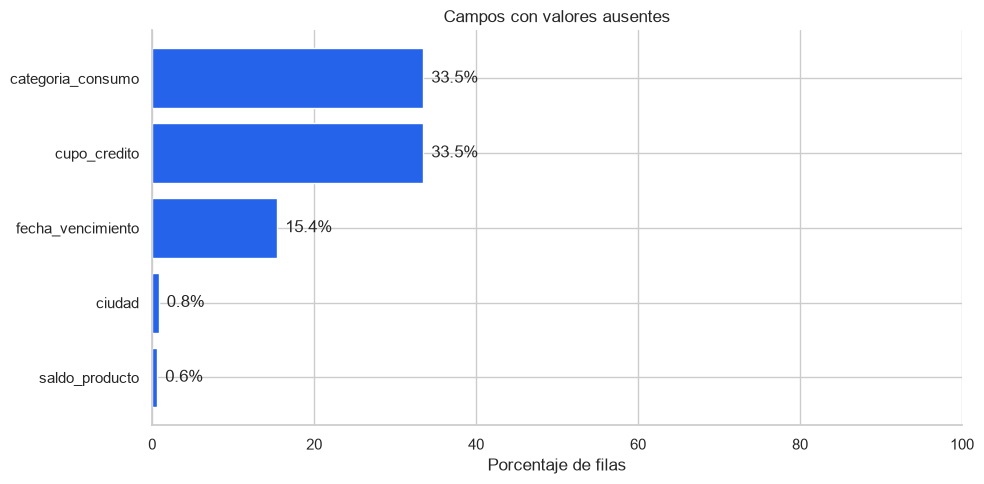

In [5]:
null_profile = (
    pd.DataFrame(
        {
            "Nulos": data.isna().sum(),
            "Porcentaje": data.isna().mean() * 100,
        }
    )
    .sort_values("Nulos", ascending=False)
    .rename_axis("Campo")
)
display(null_profile)

figure, axis = plt.subplots(figsize=(10, 5))
chart_data = null_profile[null_profile["Nulos"] > 0].sort_values("Porcentaje")
axis.barh(chart_data.index, chart_data["Porcentaje"], color="#2563EB")
axis.set_title("Campos con valores ausentes")
axis.set_xlabel("Porcentaje de filas")
axis.set_ylabel("")
axis.set_xlim(0, 100)
for position, value in enumerate(chart_data["Porcentaje"]):
    axis.text(value + 1, position, f"{value:.1f}%", va="center")
sns.despine()
plt.tight_layout()
plt.show()

In [6]:
is_credit_card = data["producto"].eq("Tarjeta de Crédito")
is_deposit = data["producto"].isin(["Cuenta de Ahorros", "Cuenta Corriente"])
valid_city_clients = set(data.loc[data["ciudad"].notna(), "cliente_id"])

city_missing_rows = int(data["ciudad"].isna().sum())
recoverable_city_rows = int(
    (data["ciudad"].isna() & data["cliente_id"].isin(valid_city_clients)).sum()
)
clients_without_city = int(
    data.groupby("cliente_id")["ciudad"].apply(lambda values: values.notna().sum() == 0).sum()
)

data_without_exact_duplicates = data.drop_duplicates().copy()
product_groups = data_without_exact_duplicates.groupby(["cliente_id", "producto"])
product_groups_without_balance = int(
    product_groups["saldo_producto"].apply(lambda values: values.notna().sum() == 0).sum()
)

null_semantics = pd.DataFrame(
    [
        ["cupo_credito", "Estructural", int(data.loc[~is_credit_card, "cupo_credito"].isna().sum()), "No aplica fuera de tarjeta"],
        ["categoria_consumo", "Estructural", int(data.loc[~is_credit_card, "categoria_consumo"].isna().sum()), "No aplica fuera de tarjeta"],
        ["fecha_vencimiento", "Estructural", int(data.loc[is_deposit, "fecha_vencimiento"].isna().sum()), "No aplica a depósitos"],
        ["ciudad", "Recuperable", recoverable_city_rows, "Usar otra fila del mismo cliente"],
        ["ciudad", "No recuperable", clients_without_city, "Asignar Desconocida en Fase 2"],
        ["saldo_producto", "No recuperable", product_groups_without_balance, "Conservar nulo y agregar bandera"],
    ],
    columns=["Campo", "Clasificación", "Casos", "Tratamiento propuesto"],
)
display(null_semantics)

structural_null_checks = pd.DataFrame(
    {
        "Regla": [
            "Cupo nulo fuera de tarjeta",
            "Categoría nula fuera de tarjeta",
            "Vencimiento nulo en depósitos",
            "Cupo informado solo en tarjeta",
            "Consumo cero fuera de tarjeta",
        ],
        "Resultado": [
            bool(data.loc[~is_credit_card, "cupo_credito"].isna().all()),
            bool(data.loc[~is_credit_card, "categoria_consumo"].isna().all()),
            bool(data.loc[is_deposit, "fecha_vencimiento"].isna().all()),
            bool(data.loc[data["cupo_credito"].notna(), "producto"].eq("Tarjeta de Crédito").all()),
            bool(data.loc[~is_credit_card, "monto_consumo"].eq(0).all()),
        ],
    }
)
display(structural_null_checks)

,Campo,Clasificación,Casos,Tratamiento propuesto
0,cupo_credito,Estructural,7513,No aplica fuera de tarjeta
1,categoria_consumo,Estructural,7513,No aplica fuera de tarjeta
2,fecha_vencimiento,Estructural,3464,No aplica a depósitos
3,ciudad,Recuperable,177,Usar otra fila del mismo cliente
4,ciudad,No recuperable,1,Asignar Desconocida en Fase 2
5,saldo_producto,No recuperable,8,Conservar nulo y agregar bandera


,Regla,Resultado
0,Cupo nulo fuera de tarjeta,True
1,Categoría nula fuera de tarjeta,True
2,Vencimiento nulo en depósitos,True
3,Cupo informado solo en tarjeta,True
4,Consumo cero fuera de tarjeta,True


### 6. Unicidad: duplicados exactos frente a registros repetidos

In [7]:
exact_duplicate_count = int(data.duplicated().sum())
rows_in_duplicate_sets = int(data.duplicated(keep=False).sum())

duplicate_summary = pd.DataFrame(
    {
        "Métrica": ["Duplicados adicionales", "Filas involucradas", "% de filas adicionales"],
        "Valor": [
            exact_duplicate_count,
            rows_in_duplicate_sets,
            exact_duplicate_count / len(data) * 100,
        ],
    }
)
display(duplicate_summary)

duplicates_by_product = (
    data.loc[data.duplicated(keep="first"), "producto"]
    .value_counts()
    .rename_axis("Producto")
    .to_frame("Duplicados adicionales")
)
display(duplicates_by_product)

,Métrica,Valor
0,Duplicados adicionales,113.00
1,Filas involucradas,226.00
2,% de filas adicionales,0.50


,Duplicados adicionales
Producto,
Tarjeta de Crédito,69
Cuenta de Ahorros,11
Cuenta Corriente,10
Crédito Hipotecario,9
Crédito Vehicular,8
Crédito de Consumo,6


In [8]:
client_product_sizes = (
    data_without_exact_duplicates.groupby(["cliente_id", "producto"])
    .size()
    .rename("registros")
    .reset_index()
)
client_product_group_count = len(client_product_sizes)
repeated_client_product_groups = int((client_product_sizes["registros"] > 1).sum())

repetitions_by_product = (
    client_product_sizes.groupby("producto")
    .agg(
        combinaciones=("cliente_id", "size"),
        combinaciones_repetidas=("registros", lambda values: int((values > 1).sum())),
        registros_promedio=("registros", "mean"),
        maximo_registros=("registros", "max"),
    )
    .sort_values("combinaciones_repetidas", ascending=False)
)
display(repetitions_by_product)

display(
    Markdown(
        f"**Lectura:** hay {client_product_group_count:,} combinaciones cliente-producto; "
        f"{repeated_client_product_groups:,} tienen varias filas. Estas repeticiones aparecen "
        "en todos los tipos de producto y no deben confundirse con duplicados exactos."
    )
)

,combinaciones,combinaciones_repetidas,registros_promedio,maximo_registros
producto,,,,
Tarjeta de Crédito,1655,1655,8.99,14
Cuenta de Ahorros,693,510,2.50,4
Cuenta Corriente,676,506,2.53,4
Crédito de Consumo,705,486,2.03,3
Crédito Hipotecario,687,443,1.99,3
Crédito Vehicular,632,402,1.94,3


**Lectura:** hay 5,048 combinaciones cliente-producto; 4,002 tienen varias filas. Estas repeticiones aparecen en todos los tipos de producto y no deben confundirse con duplicados exactos.

### 7. Consistencia de categorías

In [9]:
categorical_columns = [
    "segmento_cliente",
    "ciudad",
    "producto",
    "categoria_consumo",
    "canal",
    "estado_producto",
]

category_cardinality = pd.DataFrame(
    {
        "Campo": categorical_columns,
        "Valores distintos literales": [data_text[column].nunique() for column in categorical_columns],
        "Valores distintos analíticos": [data[column].nunique(dropna=True) for column in categorical_columns],
    }
)
display(category_cardinality)

segment_counts = data_text["segmento_cliente"].value_counts().to_frame("Filas")
consumption_category_counts = data_text["categoria_consumo"].value_counts().to_frame("Filas")
display(segment_counts)
display(consumption_category_counts)

,Campo,Valores distintos literales,Valores distintos analíticos
0,segmento_cliente,10,10
1,ciudad,7,6
2,producto,6,6
3,categoria_consumo,16,15
4,canal,5,5
5,estado_producto,1,1


,Filas
segmento_cliente,
Mass,9962
Affluent,4392
Premium,3059
Joven,2734
PyME,2037
pyme,58
Affluent,58
mass,56
JOVEN,54


,Filas
categoria_consumo,
N/A,7513
Supermarket,2221
Food,2171
Travel,1735
Streaming,1728
Technology,1668
Entertainment,1368
Others,1031
Health,995


In [10]:
normalization_candidates = pd.DataFrame(
    [
        ["segmento_cliente", "mass", "Mass", "Mayúsculas"],
        ["segmento_cliente", "JOVEN", "Joven", "Mayúsculas"],
        ["segmento_cliente", "Affluent ", "Affluent", "Espacio final"],
        ["segmento_cliente", "PREMIUM ", "Premium", "Mayúsculas y espacio"],
        ["segmento_cliente", "pyme", "PyME", "Mayúsculas"],
        ["categoria_consumo", "FOOD ", "Food", "Mayúsculas y espacio"],
        ["categoria_consumo", "streamng", "Streaming", "Error tipográfico"],
        ["categoria_consumo", "Travels", "Travel", "Plural"],
        ["categoria_consumo", "tech", "Technology", "Abreviación"],
        ["categoria_consumo", "Super Market", "Supermarket", "Espacio interno"],
    ],
    columns=["Campo", "Valor original", "Valor propuesto", "Problema"],
)
display(normalization_candidates)

,Campo,Valor original,Valor propuesto,Problema
0,segmento_cliente,mass,Mass,Mayúsculas
1,segmento_cliente,JOVEN,Joven,Mayúsculas
2,segmento_cliente,Affluent,Affluent,Espacio final
3,segmento_cliente,PREMIUM,Premium,Mayúsculas y espacio
4,segmento_cliente,pyme,PyME,Mayúsculas
5,categoria_consumo,FOOD,Food,Mayúsculas y espacio
6,categoria_consumo,streamng,Streaming,Error tipográfico
7,categoria_consumo,Travels,Travel,Plural
8,categoria_consumo,tech,Technology,Abreviación
9,categoria_consumo,Super Market,Supermarket,Espacio interno


### 8. Validez de fechas

In [11]:
def audit_dates(text_series: pd.Series) -> tuple[pd.Series, pd.Series, dict]:
    informed = ~text_series.isin(["", "N/A"])
    iso_format = informed & text_series.str.fullmatch(
        r"[0-9]{4}-[0-9]{2}-[0-9]{2}", na=False
    )
    alternative_format = informed & ~iso_format

    # Prueba solicitada: recupera todos los valores, pero puede intercambiar
    # mes y día en fechas ISO ambiguas cuando dayfirst=True.
    parsed_mixed = pd.to_datetime(
        text_series.replace({"": pd.NA, "N/A": pd.NA}),
        format="mixed",
        dayfirst=True,
        errors="coerce",
    )

    # Lectura segura propuesta para la Fase 2: cada patrón tiene su formato.
    parsed_strict = pd.Series(pd.NaT, index=text_series.index, dtype="datetime64[ns]")
    parsed_strict.loc[iso_format] = pd.to_datetime(
        text_series.loc[iso_format], format="%Y-%m-%d", errors="coerce"
    )
    parsed_strict.loc[alternative_format] = pd.to_datetime(
        text_series.loc[alternative_format], format="%d/%m/%Y", errors="coerce"
    )

    changed_by_mixed = int(
        (
            parsed_mixed.notna()
            & parsed_strict.notna()
            & parsed_mixed.ne(parsed_strict)
        ).sum()
    )
    summary = {
        "Valores informados": int(informed.sum()),
        "No ISO": int(alternative_format.sum()),
        "No interpretados (mixed)": int((informed & parsed_mixed.isna()).sum()),
        "No interpretados (estricto)": int((informed & parsed_strict.isna()).sum()),
        "Fechas alteradas por mixed + dayfirst": changed_by_mixed,
        "Fecha mínima segura": parsed_strict.min().date().isoformat(),
        "Fecha máxima segura": parsed_strict.max().date().isoformat(),
    }
    return parsed_strict, parsed_mixed, summary

movement_dates_parsed, movement_dates_mixed, movement_date_summary = audit_dates(
    data_text["fecha_movimiento"]
)
expiration_dates_parsed, expiration_dates_mixed, expiration_date_summary = audit_dates(
    data_text["fecha_vencimiento"]
)

date_audit = pd.DataFrame(
    [movement_date_summary, expiration_date_summary],
    index=["fecha_movimiento", "fecha_vencimiento"],
)
display(date_audit)

cutoff_date = movement_dates_parsed.max()
non_iso_movement_count = movement_date_summary["No ISO"]
invalid_mixed_movement_count = movement_date_summary["No interpretados (mixed)"]
invalid_strict_movement_count = movement_date_summary["No interpretados (estricto)"]
dates_changed_by_mixed = movement_date_summary[
    "Fechas alteradas por mixed + dayfirst"
]
display(
    Markdown(
        f"**Fecha de corte reproducible:** {cutoff_date.date().isoformat()}. "
        f"La lectura mixta no pierde fechas, pero altera {dates_changed_by_mixed:,} "
        "valores ISO ambiguos; por eso no se utilizará sola en la limpieza."
    )
)

,Valores informados,No ISO,No interpretados (mixed),No interpretados (estricto),Fechas alteradas por mixed + dayfirst,Fecha mínima segura,Fecha máxima segura
fecha_movimiento,22455,89,0,0,8182,2025-01-01,2026-08-31
fecha_vencimiento,18991,0,0,0,6902,2026-09-17,2032-09-08


**Fecha de corte reproducible:** 2026-08-31. La lectura mixta no pierde fechas, pero altera 8,182 valores ISO ambiguos; por eso no se utilizará sola en la limpieza.

### 9. Variables numéricas y valores extremos

In [12]:
numeric_columns = [
    "edad",
    "ingreso_estimado",
    "saldo_producto",
    "cupo_credito",
    "monto_consumo",
]

numeric_summary = data[numeric_columns].describe(
    percentiles=[0.01, 0.25, 0.50, 0.75, 0.99]
).T
display(numeric_summary)

numeric_quality = pd.DataFrame(
    {
        "Nulos": data[numeric_columns].isna().sum(),
        "Ceros": [(data[column] == 0).sum() for column in numeric_columns],
        "Negativos": [(data[column] < 0).sum() for column in numeric_columns],
    }
)
display(numeric_quality)

,count,mean,std,min,1%,25%,50%,75%,99%,max
edad,"22,455.00",38.74,11.38,18.00,18.00,31.00,39.00,47.00,66.00,78.00
ingreso_estimado,"22,455.00","1,881.73","1,539.29",350.00,366.30,798.77,"1,255.17","2,534.15","7,075.74","16,177.54"
saldo_producto,"22,319.00","7,611.06","19,006.17",-100.00,-100.00,468.68,"1,280.13","4,040.84","99,999.47","158,165.51"
cupo_credito,"14,942.00","3,710.43","3,360.03",500.00,600.00,"1,500.00","2,500.00","4,700.00","16,500.00","29,300.00"
monto_consumo,"22,455.00",83.33,156.41,0.00,0.00,0.00,32.30,97.87,724.87,"3,712.08"


,Nulos,Ceros,Negativos
edad,0,0,0
ingreso_estimado,0,0,0
saldo_producto,136,776,302
cupo_credito,7513,0,0
monto_consumo,0,7513,0


In [13]:
balance_by_product = (
    data.groupby("producto")["saldo_producto"]
    .agg(
        registros="count",
        nulos=lambda values: int(values.isna().sum()),
        negativos=lambda values: int((values < 0).sum()),
        ceros=lambda values: int((values == 0).sum()),
        mediana="median",
        minimo="min",
        maximo="max",
    )
    .sort_values("mediana")
)
display(balance_by_product)

negative_balance_products = set(
    data.loc[data["saldo_producto"] < 0, "producto"].unique()
)

,registros,nulos,negativos,ceros,mediana,minimo,maximo
producto,,,,,,,
Tarjeta de Crédito,14852,90,0,772,718.83,0.00,"18,157.12"
Cuenta de Ahorros,1733,8,149,0,"2,506.57",-100.00,"49,425.12"
Cuenta Corriente,1712,11,153,0,"2,651.17",-100.00,"35,349.58"
Crédito de Consumo,1427,12,0,0,"5,859.37",115.30,"43,034.16"
Crédito Vehicular,1228,4,0,1,"17,983.16",0.00,"38,261.64"
Crédito Hipotecario,1367,11,0,3,"74,186.47",0.00,"158,165.51"


> **Criterio:** IQR identifica valores alejados de la distribución de su grupo. Una bandera estadística no demuestra que el dato sea erróneo. Por eso la Fase 2 conservará el valor y añadirá una marca de revisión.

In [14]:
def iqr_profile(frame: pd.DataFrame, group_column: str, value_column: str) -> pd.DataFrame:
    rows = []
    for group_name, values in frame.groupby(group_column)[value_column]:
        valid_values = values.dropna()
        q1 = valid_values.quantile(0.25)
        q3 = valid_values.quantile(0.75)
        iqr = q3 - q1
        lower_limit = q1 - 1.5 * iqr
        upper_limit = q3 + 1.5 * iqr
        outlier_count = int(
            ((valid_values < lower_limit) | (valid_values > upper_limit)).sum()
        )
        rows.append(
            {
                "Grupo": group_name,
                "Observaciones": len(valid_values),
                "Q1": q1,
                "Q3": q3,
                "Límite inferior": lower_limit,
                "Límite superior": upper_limit,
                "Posibles outliers": outlier_count,
                "% posibles outliers": outlier_count / len(valid_values) * 100,
            }
        )
    return pd.DataFrame(rows).set_index("Grupo")

balance_iqr = iqr_profile(data, "producto", "saldo_producto")
positive_consumptions = data.loc[
    data["monto_consumo"].gt(0) & data["categoria_consumo"].notna()
]
consumption_iqr = iqr_profile(
    positive_consumptions,
    "categoria_consumo",
    "monto_consumo",
)

display(balance_iqr)
display(consumption_iqr.sort_values("% posibles outliers", ascending=False))

,Observaciones,Q1,Q3,Límite inferior,Límite superior,Posibles outliers,% posibles outliers
Grupo,,,,,,,
Crédito Hipotecario,1367,"56,506.19","90,600.90","5,364.13","141,742.96",15,1.10
Crédito Vehicular,1228,"13,851.00","22,115.73","1,453.91","34,512.82",11,0.90
Crédito de Consumo,1427,"3,685.74","13,233.53","-10,635.95","27,555.23",38,2.66
Cuenta Corriente,1712,"1,200.87","6,341.33","-6,509.82","14,052.02",72,4.21
Cuenta de Ahorros,1733,"1,139.31","5,679.82","-5,671.45","12,490.58",148,8.54
Tarjeta de Crédito,14852,356.20,"1,536.17","-1,413.77","3,306.14",1138,7.66


,Observaciones,Q1,Q3,Límite inferior,Límite superior,Posibles outliers,% posibles outliers
Grupo,,,,,,,
Travels,29,48.20,118.85,-57.77,224.82,6,20.69
streamng,30,32.07,87.51,-51.08,170.67,4,13.33
Super Market,18,29.10,119.33,-106.26,254.69,2,11.11
Education,947,33.67,148.65,-138.79,321.12,83,8.76
Others,1031,32.09,154.06,-150.84,337.00,88,8.54
Streaming,1728,32.45,145.12,-136.54,314.11,147,8.51
Travel,1735,32.86,154.56,-149.69,337.12,147,8.47
FOOD,36,25.34,188.76,-219.77,433.88,3,8.33
Food,2171,33.98,147.29,-136.00,317.26,177,8.15


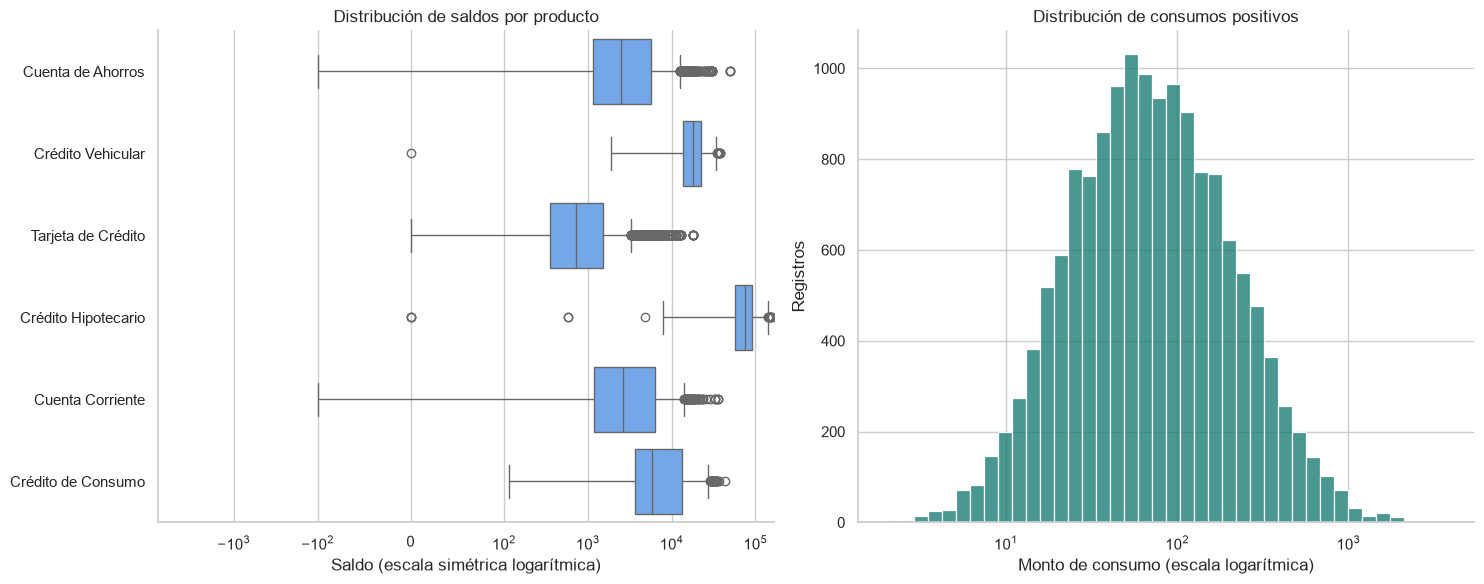

In [15]:
figure, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.boxplot(
    data=data,
    y="producto",
    x="saldo_producto",
    color="#60A5FA",
    ax=axes[0],
)
axes[0].set_xscale("symlog", linthresh=100)
axes[0].set_title("Distribución de saldos por producto")
axes[0].set_xlabel("Saldo (escala simétrica logarítmica)")
axes[0].set_ylabel("")

sns.histplot(
    positive_consumptions,
    x="monto_consumo",
    bins=40,
    log_scale=(True, False),
    color="#0F766E",
    ax=axes[1],
)
axes[1].set_title("Distribución de consumos positivos")
axes[1].set_xlabel("Monto de consumo (escala logarítmica)")
axes[1].set_ylabel("Registros")

sns.despine()
plt.tight_layout()
plt.show()

### 10. Consistencia de clientes y productos

In [16]:
client_attributes = [
    "nombre_cliente",
    "segmento_cliente",
    "ciudad",
    "edad",
    "ingreso_estimado",
]

client_conflicts = pd.DataFrame(
    {
        "Clientes con más de una versión, contando nulos": {
            column: int(
                (
                    data_without_exact_duplicates.groupby("cliente_id")[column]
                    .nunique(dropna=False)
                    > 1
                ).sum()
            )
            for column in client_attributes
        },
        "Clientes con más de una versión no nula": {
            column: int(
                (
                    data_without_exact_duplicates.groupby("cliente_id")[column]
                    .nunique(dropna=True)
                    > 1
                ).sum()
            )
            for column in client_attributes
        },
    }
)

segment_normalized_for_audit = (
    data_without_exact_duplicates["segmento_cliente"]
    .astype("string")
    .str.strip()
    .str.casefold()
)
segment_conflicts_after_normalization = int(
    segment_normalized_for_audit.groupby(data_without_exact_duplicates["cliente_id"])
    .nunique(dropna=True)
    .gt(1)
    .sum()
)
segment_conflicts_raw = int(
    client_conflicts.loc[
        "segmento_cliente",
        "Clientes con más de una versión no nula",
    ]
)
segment_conflicts_resolved_by_formatting = (
    segment_conflicts_raw - segment_conflicts_after_normalization
)

unresolved_segment_examples = (
    data_without_exact_duplicates.assign(
        segmento_normalizado=segment_normalized_for_audit
    )
    .groupby("cliente_id")["segmento_normalizado"]
    .agg(lambda values: sorted(values.dropna().unique().tolist()))
)
unresolved_segment_examples = unresolved_segment_examples.loc[
    unresolved_segment_examples.str.len().gt(1)
].head(10).to_frame("Segmentos normalizados observados")

display(client_conflicts)
display(
    Markdown(
        f"De los **{segment_conflicts_raw} clientes** con más de un segmento literal, "
        f"solo **{segment_conflicts_resolved_by_formatting}** se explican por mayúsculas o espacios. "
        f"Quedan **{segment_conflicts_after_normalization} clientes con segmentos canónicos distintos**. "
        "Sin una regla de negocio no es correcto escoger uno silenciosamente."
    )
)
display(unresolved_segment_examples)

,"Clientes con más de una versión, contando nulos",Clientes con más de una versión no nula
nombre_cliente,0,0
segmento_cliente,251,251
ciudad,170,0
edad,0,0
ingreso_estimado,0,0


De los **251 clientes** con más de un segmento literal, solo **40** se explican por mayúsculas o espacios. Quedan **211 clientes con segmentos canónicos distintos**. Sin una regla de negocio no es correcto escoger uno silenciosamente.

,Segmentos normalizados observados
cliente_id,
C000001,"[affluent, mass]"
C000002,"[mass, pyme]"
C000019,"[mass, premium]"
C000024,"[mass, premium]"
C000050,"[affluent, mass]"
C000067,"[joven, premium]"
C000078,"[affluent, mass]"
C000082,"[affluent, mass]"
C000084,"[joven, premium]"


In [17]:
product_attribute_conflicts = pd.DataFrame(
    {
        column: product_groups[column]
        .nunique(dropna=True)
        .gt(1)
        .value_counts()
        .reindex([False, True], fill_value=0)
        for column in ["saldo_producto", "cupo_credito", "fecha_vencimiento"]
    }
).T
product_attribute_conflicts.columns = ["Grupos consistentes", "Grupos con conflicto"]
display(product_attribute_conflicts)

,Grupos consistentes,Grupos con conflicto
saldo_producto,5048,0
cupo_credito,5048,0
fecha_vencimiento,5048,0


### 11. Riesgo de doble conteo

In [18]:
product_snapshot_for_audit = (
    product_groups["saldo_producto"]
    .first()
    .rename("saldo_producto")
    .reset_index()
)

raw_balance_total = float(data["saldo_producto"].sum())
deduplicated_row_balance_total = float(data_without_exact_duplicates["saldo_producto"].sum())
product_level_balance_total = float(product_snapshot_for_audit["saldo_producto"].sum())

raw_card_balance = float(
    data.loc[data["producto"].eq("Tarjeta de Crédito"), "saldo_producto"].sum()
)
product_level_card_balance = float(
    product_snapshot_for_audit.loc[
        product_snapshot_for_audit["producto"].eq("Tarjeta de Crédito"),
        "saldo_producto",
    ].sum()
)

balance_reconciliation = pd.DataFrame(
    [
        ["Todas las filas originales", raw_balance_total, raw_balance_total / product_level_balance_total],
        ["Filas sin duplicados exactos", deduplicated_row_balance_total, deduplicated_row_balance_total / product_level_balance_total],
        ["Una fila por cliente-producto", product_level_balance_total, 1.0],
        ["Tarjetas: todas las filas", raw_card_balance, raw_card_balance / product_level_card_balance],
        ["Tarjetas: una fila por cliente-producto", product_level_card_balance, 1.0],
    ],
    columns=["Cálculo", "Saldo", "Factor frente a producto"],
)
display(balance_reconciliation)

display(
    Markdown(
        f"Sumar desde el archivo original infla el saldo general **{raw_balance_total / product_level_balance_total:.2f} veces**. "
        f"En tarjetas, el factor llega a **{raw_card_balance / product_level_card_balance:.2f} veces**. "
        "Por esta razón la Fase 2 separará productos de consumos."
    )
)

,Cálculo,Saldo,Factor frente a producto
0,Todas las filas originales,"169,871,166.14",2.20
1,Filas sin duplicados exactos,"168,666,319.46",2.18
2,Una fila por cliente-producto,"77,356,909.02",1.00
3,Tarjetas: todas las filas,"18,042,718.54",8.94
4,Tarjetas: una fila por cliente-producto,"2,018,033.83",1.00


Sumar desde el archivo original infla el saldo general **2.20 veces**. En tarjetas, el factor llega a **8.94 veces**. Por esta razón la Fase 2 separará productos de consumos.

### 12. Hallazgos de calidad y contrato de limpieza

In [19]:
quality_findings = pd.DataFrame(
    [
        ["Granularidad mixta", "Saldo general inflado 2,20 veces", "Separar productos de registros y consumos", "Crítico: KPIs financieros erróneos", "Reconciliar suma cruda contra una fila cliente-producto"],
        ["Sin ID transaccional", "No se puede probar que dos compras idénticas sean la misma", "Documentar supuesto y crear ID determinista", "Alto: eliminar una operación real", "Conservar trazabilidad y contar filas antes/después"],
        ["Duplicados exactos", "113 filas adicionales (0,50%)", "Eliminar solo coincidencias exactas", "Medio: sobreconteo", "Esperar 22.342 registros tras deduplicar"],
        ["Categorías inconsistentes", "10 variantes conocidas", "Aplicar diccionarios explícitos", "Medio: categorías fragmentadas", "Lista cerrada y cero variantes conocidas remanentes"],
        ["Segmento conflictivo por cliente", "211 clientes conservan más de un segmento tras normalizar formato", "Definir regla determinista y conservar bandera", "Alto: perfil comercial ambiguo", "Una fila por cliente más indicador de conflicto"],
        ["Fechas mixtas", "89 alternativas; mixed + dayfirst altera 8.182 ISO ambiguas", "Detectar patrón y parsear cada formato explícitamente", "Alto: recencia y corte equivocados", "Cero inválidas y rango 2025-01-01 a 2026-08-31"],
        ["Ciudad y saldo incompletos", "178 filas de ciudad y 136 de saldo", "Recuperar dentro de entidad; conservar excepción", "Medio: filtros y saldos incompletos", "Un cliente sin ciudad y ocho productos sin saldo"],
        ["Negativos y extremos", "Solo hay negativos en depósitos; IQR marca extremos", "Conservar valor y agregar bandera", "Bajo: pérdida si se corrige sin negocio", "Mismo valor original y bandera auditable"],
    ],
    columns=["Problema", "Evidencia", "Tratamiento propuesto", "Riesgo", "Validación de Fase 2"],
)
display(quality_findings)

cleaning_contract = pd.DataFrame(
    [
        ["dataset_clean.csv", "Registro fuente no duplicado", "Preservar fecha, canal y campos normalizados"],
        ["dim_clientes.csv", "Un cliente", "Atributos estables para filtros"],
        ["fact_productos.csv", "Un cliente-producto", "Saldos, cupos y vencimientos sin repetición"],
        ["fact_consumos.csv", "Un consumo positivo de tarjeta", "Categorías, montos y comportamiento"],
        ["cliente_360.csv / .json", "Un cliente", "Consumo por React y análisis ejecutivo"],
    ],
    columns=["Salida de Fase 2", "Granularidad", "Propósito"],
)
display(cleaning_contract)

,Problema,Evidencia,Tratamiento propuesto,Riesgo,Validación de Fase 2
0,Granularidad mixta,"Saldo general inflado 2,20 veces",Separar productos de registros y consumos,Crítico: KPIs financieros erróneos,Reconciliar suma cruda contra una fila cliente...
1,Sin ID transaccional,No se puede probar que dos compras idénticas s...,Documentar supuesto y crear ID determinista,Alto: eliminar una operación real,Conservar trazabilidad y contar filas antes/de...
2,Duplicados exactos,"113 filas adicionales (0,50%)",Eliminar solo coincidencias exactas,Medio: sobreconteo,Esperar 22.342 registros tras deduplicar
3,Categorías inconsistentes,10 variantes conocidas,Aplicar diccionarios explícitos,Medio: categorías fragmentadas,Lista cerrada y cero variantes conocidas reman...
4,Segmento conflictivo por cliente,211 clientes conservan más de un segmento tras...,Definir regla determinista y conservar bandera,Alto: perfil comercial ambiguo,Una fila por cliente más indicador de conflicto
5,Fechas mixtas,89 alternativas; mixed + dayfirst altera 8.182...,Detectar patrón y parsear cada formato explíci...,Alto: recencia y corte equivocados,Cero inválidas y rango 2025-01-01 a 2026-08-31
6,Ciudad y saldo incompletos,178 filas de ciudad y 136 de saldo,Recuperar dentro de entidad; conservar excepción,Medio: filtros y saldos incompletos,Un cliente sin ciudad y ocho productos sin saldo
7,Negativos y extremos,Solo hay negativos en depósitos; IQR marca ext...,Conservar valor y agregar bandera,Bajo: pérdida si se corrige sin negocio,Mismo valor original y bandera auditable


,Salida de Fase 2,Granularidad,Propósito
0,dataset_clean.csv,Registro fuente no duplicado,"Preservar fecha, canal y campos normalizados"
1,dim_clientes.csv,Un cliente,Atributos estables para filtros
2,fact_productos.csv,Un cliente-producto,"Saldos, cupos y vencimientos sin repetición"
3,fact_consumos.csv,Un consumo positivo de tarjeta,"Categorías, montos y comportamiento"
4,cliente_360.csv / .json,Un cliente,Consumo por React y análisis ejecutivo


### 13. Validaciones automáticas

In [20]:
product_conflict_counts = {
    column: int(product_groups[column].nunique(dropna=True).gt(1).sum())
    for column in ["saldo_producto", "cupo_credito", "fecha_vencimiento"]
}

assert data.shape == (22455, 15)
assert data["cliente_id"].nunique() == 2200
assert exact_duplicate_count == 113
assert city_missing_rows == 178
assert int(data["saldo_producto"].isna().sum()) == 136
assert int(data["cupo_credito"].isna().sum()) == 7513
assert int(data["categoria_consumo"].isna().sum()) == 7513
assert int(data["fecha_vencimiento"].isna().sum()) == 3464
assert clients_without_city == 1
assert structural_null_checks["Resultado"].all()
assert non_iso_movement_count == 89
assert invalid_mixed_movement_count == 0
assert invalid_strict_movement_count == 0
assert dates_changed_by_mixed == 8182
assert client_product_group_count == 5048
assert repeated_client_product_groups == 4002
assert product_groups_without_balance == 8
assert product_conflict_counts == {
    "saldo_producto": 0,
    "cupo_credito": 0,
    "fecha_vencimiento": 0,
}
assert negative_balance_products == {"Cuenta de Ahorros", "Cuenta Corriente"}
assert segment_conflicts_raw == 251
assert segment_conflicts_resolved_by_formatting == 40
assert segment_conflicts_after_normalization == 211
assert cutoff_date.date().isoformat() == "2026-08-31"
assert abs(raw_balance_total - 169871166.14) < 0.01
assert abs(product_level_balance_total - 77356909.02) < 0.01
assert abs(raw_card_balance - 18042718.54) < 0.01
assert abs(product_level_card_balance - 2018033.83) < 0.01

print("Todas las validaciones de la Fase 1 se ejecutaron correctamente.")

Todas las validaciones de la Fase 1 se ejecutaron correctamente.


## Conclusiones y siguientes pasos

1. **El dataset puede utilizarse después de una limpieza controlada.** La mayoría de los problemas son consistentes y tienen una regla defendible.
2. **La granularidad es el riesgo de mayor impacto.** Los KPIs de cartera deben calcularse desde una tabla cliente-producto, no desde los registros originales.
3. **Los nulos deben tratarse según contexto.** Algunos significan “no aplica”; otros pueden recuperarse y ocho productos conservarán saldo desconocido.
4. **Las fechas son recuperables con lectura explícita.** Los 89 valores no ISO son válidos bajo formato día/mes/año; aplicar `mixed + dayfirst` a toda la columna alteraría 8.182 fechas ISO ambiguas.
5. **Los extremos no se eliminarán.** Se conservarán con banderas para evitar destruir información potencialmente real.
6. **El segmento requiere una regla de consolidación.** De 251 clientes con más de una etiqueta, 40 se resuelven por formato; 211 conservan segmentos realmente distintos y deben quedar señalados hasta acordar una precedencia.

### Qué debes poder explicar

- El archivo mezcla información de cliente, fotografía de producto e interacción o consumo.
- Un registro repetido no es automáticamente un duplicado.
- Un nulo no es automáticamente cero.
- Consolidar producto antes de sumar evita inflar el saldo.
- Normalizar texto corrige etiquetas, pero no resuelve conflictos semánticos entre segmentos distintos.
- La Fase 2 implementará las reglas propuestas y exportará las cinco vistas del contrato.

**Estado de esta auditoría:** lista para compartir con las limitaciones documentadas. La limpieza permanece fuera del alcance de esta fase.